In [61]:
import os, random
import re
import pyreadr
import numpy as np
import pandas as pd
import warnings
import optuna
from scipy import stats
import tensorflow as tf
from typing import List, Tuple
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import ElasticNetCV
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from statsmodels.tools.sm_exceptions import ConvergenceWarning, PerfectSeparationWarning
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras import losses  # For mse
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import load_model
import tensorflow.keras.metrics as metrics
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform

# Shutdown warnings
warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", PerfectSeparationWarning)
# Suppress all sklearn convergence warnings globally
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# -----------------------------------------------------------------
# Set working directory
wkdir = r"C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01transcriptome/00data/"
os.chdir(wkdir)

# -----------------------------------------------------------------
# File paths
#uthbCounts = r"00uthb_genecounts-08152025.csv.gz"
vabbCounts = r"00vabb_genecounts-08152025.csv.gz"

# Reading annotation
#uthbAnnot = r"00uthb_annotation-08152025.csv.gz"
vabbAnnot = r"00vabb_annotation-08152025.csv.gz"

# -----------------------------------------------------------------
# Read gzipped CSVs
#expr_uthb = pd.read_csv(uthbCounts, index_col=0, compression='gzip')
expr_vabb = pd.read_csv(vabbCounts, index_col=0, compression='gzip')
#annot_uthb = pd.read_csv(uthbAnnot, index_col=0, compression='gzip')
annot_vabb = pd.read_csv(vabbAnnot, index_col=0, compression='gzip')

# -----------------------------------------------------------------

In [3]:
# -----------------------------------------------------------------
# Loading metadata
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/00vabb/00PhenoMeta_trainclock-07272025.csv"
phenoData = pd.read_csv(phenoPath)
# Create suffixes
suffixes = ["_9", "_24", "_25", "_11"]
# Replicate and modify pheno_data
phenoData = pd.concat([
    phenoData.assign(SampleID="Sample" + phenoData["SampleID"].astype(str) + suffix)
    for suffix in suffixes
], ignore_index=True)
phenoData.shape
# -----------------------------------------------------------------

(564, 6)

In [4]:
# Load cell types and SVAs
cells = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/05celltype-08042025/00vabb_cellprop_svas-08042025.csv")
cells = cells.rename(columns={'name': 'SampleID'})
cells.shape

(551, 17)

In [5]:
# Merge in sequence after conversion
merged_df_com = pd.merge(phenoData, cells, on='SampleID')
meta = merged_df_com
meta.shape

(546, 22)

In [6]:
# -----------------------------------------------------------------
# Subset meta to only required columns
meta = meta[['SampleID', 'Sex', 'PMI', 'RIN', 'AgeDeath', 'ast', 'end', 'mic', 'neu', 'oli', 'opc', 'W_1', 'W_2']]
# Columns not to scale
exclude_cols = ['SampleID', 'Sex', 'AgeDeath']

# Identify columns to scale
cols_to_scale = [col for col in meta.columns if col not in exclude_cols]

# Initialize scaler
scaler = StandardScaler(with_mean=True, with_std=True)

# Scale selected columns
meta_scaled = meta.copy()
meta_scaled[cols_to_scale] = scaler.fit_transform(meta_scaled[cols_to_scale])
# Set SampleID as index
meta_scaled = meta_scaled.set_index('SampleID')
meta_scaled.head()

,Sex,PMI,RIN,AgeDeath,ast,end,mic,neu,oli,opc,W_1,W_2
SampleID,,,,,,,,,,,,
Sample5205_9,Male,1.344314,1.002963,51,-0.985183,-0.718509,-0.410640,-0.266188,-0.664003,-0.952803,-0.108106,-0.192520
Sample5228_9,Female,0.646458,-1.095190,58,-0.633027,-0.839082,-0.563833,-0.297959,-0.658491,-0.931297,-0.037179,-0.167703
Sample5286_9,Female,0.879077,-1.394926,44,0.176086,0.233682,2.609995,0.242871,0.001352,0.322115,21.817682,2.574510
Sample5287_9,Male,1.189235,0.303579,40,-0.590237,-0.925822,-0.597451,-0.393386,-0.697382,-1.016107,-0.065587,-0.121521
Sample5323_9,Male,0.181221,-0.395805,35,-1.143411,-0.719600,-0.327777,-0.647711,-0.780717,-0.976483,-0.044045,-0.022014


In [7]:
# -----------------------------------------------------------------
# Function to clean sample names
def clean_sample_name(name):
    # Match "Sample<number><letters><number>" and replace with "Sample<number>_<number>"
    return re.sub(r"(Sample\d+)[A-Za-z]+(\d+)", r"\1_\2", name)

# Apply to a DataFrame
# Example: expr_uthb.columns = [clean_sample_name(c) for c in expr_uthb.columns]
expr_vabb.columns = [clean_sample_name(c) for c in expr_vabb.columns]
expr_vabb.head()
# -----------------------------------------------------------------

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000284662,28,24,11,21,9,12,0,2,9,32,...,1,3,23,38,56,29,15,11,31,20
ENSG00000186827,10,16,9,5,2,9,9,17,3,45,...,11,6,33,7,91,26,8,10,73,29
ENSG00000186891,8,32,12,2,5,15,13,34,23,48,...,33,8,43,6,80,25,19,37,57,23
ENSG00000160072,529,1015,372,358,497,286,674,1161,504,1667,...,480,505,1633,714,4695,1521,573,959,3142,1684
ENSG00000041988,65,144,102,82,60,114,174,279,122,312,...,196,188,321,196,1103,375,108,259,729,373


In [8]:
# -----------------------------------------------------------------
# Define a function for the estimation FPKM of transcriptome data
def counts_to_fpkm(counts: pd.DataFrame, gene_lengths: pd.Series, lengths_in: str = "bp") -> pd.DataFrame:
    """
    Convert raw counts to FPKM.
    counts: genes x samples
    gene_lengths: length per gene (index aligned to counts)
    lengths_in: 'bp' or 'kb'
    """
    assert set(counts.index).issubset(set(gene_lengths.index)), "Gene lengths missing for some genes"  
    # Convert lengths to kilobases
    L = gene_lengths.loc[counts.index].astype(float)
    if lengths_in == "bp":
        L = L / 1e3
    elif lengths_in != "kb":
        raise ValueError("lengths_in must be 'bp' or 'kb'")
        
    # RPK: counts / length_kb
    rpk = counts.divide(L, axis=0)
    
    # FPKM: RPK / (total_mapped_reads_in_millions)
    per_sample_scaler = counts.sum(axis=0) / 1e6
    fpkm = rpk.divide(per_sample_scaler, axis=1)
    
    return fpkm

# -----------------------------------------------------------------
# Define a function for the estimation of gene lengths
def extract_gene_bounds(df: pd.DataFrame, start_col='Start', end_col='End'):
    """
    Extract first start and last end for genes where Start/End columns may contain multiple positions separated by ';'.
    
    Args:
        df: DataFrame with at least 'GeneID', start_col, end_col
        start_col: name of the start column
        end_col: name of the end column
        
    Returns:
        DataFrame with 'GeneID', 'Start', 'End', 'GeneLength'
    """
    starts = []
    ends = []
    for s, e in zip(df[start_col], df[end_col]):
        # Split by ',' and convert to int
        start_vals = [int(x) for x in str(s).split(';') if x.strip().isdigit()]
        end_vals   = [int(x) for x in str(e).split(';') if x.strip().isdigit()]
        if start_vals and end_vals:
            starts.append(min(start_vals))  # first start = smallest
            ends.append(max(end_vals))      # last end = largest
        else:
            starts.append(None)
            ends.append(None)
    
    result = pd.DataFrame({
        'GeneID': df['GeneID'],
        'Start': starts,
        'End': ends
    })
    
    # Compute gene length
    result['GeneLength'] = result['End'] - result['Start'] + 1
    return result

In [9]:
# -----------------------------------------------------------------
# Transforming to FPKM
gene_info_vabb = extract_gene_bounds(annot_vabb)
# Make Series: index = GeneID, values = GeneLength
gene_lengths = pd.Series(gene_info_vabb["GeneLength"].values, index=gene_info_vabb["GeneID"])
fpkm_matrix = counts_to_fpkm(expr_vabb, gene_lengths, lengths_in="bp")
fpkm_matrix.shape

(60605, 551)

In [10]:
# -----------------------------------------------------------------
# Filtering to FPKM
# To avoid the influence of low count genes on the analysis result, genes with more than 30% samples having count per million (CPM) less than one were filtered out
mfilter = (fpkm_matrix < 1).sum(axis=1) / fpkm_matrix.shape[1] <= 0.3
fpkm_matrix = fpkm_matrix.loc[mfilter]  # assign back
fpkm_matrix.shape

(9105, 551)

In [11]:
# -----------------------------------------------------------------
# Standardize by gene (rows)
scaler = StandardScaler(with_mean=True, with_std=True)
expr_z = pd.DataFrame(
    scaler.fit_transform(fpkm_matrix.T).T,  # transpose -> scale -> transpose back
    index=fpkm_matrix.index,  # keep gene names
    columns=fpkm_matrix.columns  # keep sample names
)
expr_z.head()

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000160072,1.032523,1.711955,-0.085869,0.626116,0.142356,-1.534350,1.616278,1.263234,-0.076390,1.512895,...,-1.172818,-1.516864,0.582666,-1.194454,0.640007,0.532361,0.335098,-0.217445,0.644238,0.889257
ENSG00000225972,4.563008,2.811983,-0.264908,-0.292317,1.492488,1.045303,-0.526877,-0.460963,-0.016767,0.109340,...,-0.615557,-0.222504,-0.559921,-0.181519,-0.507210,-0.528148,-0.594211,-0.462490,-0.424670,-0.453273
ENSG00000224315,1.687359,1.046504,0.066807,-0.904123,-0.380758,-0.732082,-0.120664,0.096232,0.582366,0.223664,...,-0.987097,-0.856729,0.539175,0.351821,-0.847716,-0.410237,-1.351098,-0.682342,-0.145540,-0.445355
ENSG00000198744,1.343346,0.391138,0.306707,-0.097394,2.434571,0.206976,-0.331683,-0.358510,0.240591,0.187385,...,-0.827569,-0.682511,-0.790172,-0.369185,-0.779362,-0.781348,-0.841667,-0.805819,-0.807733,-0.750103
ENSG00000225630,0.955431,0.034720,-0.030795,-0.499710,2.005468,-0.202936,-1.023479,-0.962707,0.275962,0.120231,...,-0.572983,1.244179,-0.235424,1.823509,-0.246167,-0.595604,-0.130808,-0.240961,-0.328370,-0.490384


In [12]:
# -----------------------------------------------------------------
# Subsetting to only unique samples
# Example: columns in your expression matrix
columns = expr_z.columns  # expr is your genes x samples DataFrame
# Extract the prefix before the underscore
prefixes = [col.split('_')[0] for col in columns]
# Create a DataFrame to associate columns with prefixes
col_df = pd.DataFrame({'col': columns, 'prefix': prefixes})

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
# Sample one column per prefix
unique_cols = col_df.groupby('prefix')['col'].apply(lambda x: np.random.choice(x)).values
# Subset your expression matrix
expr_unique = expr_z[unique_cols]
# Check
print(expr_unique.shape)
print(expr_z.shape)

(9105, 143)
(9105, 551)


In [13]:
# -----------------------------------------------------------------
# Columns that were selected
unique_cols_set = set(unique_cols)
# Columns that were not selected
excluded_cols = [col for col in expr_z.columns if col not in unique_cols_set]
# Check
print("Number of selected columns:", len(unique_cols))
print("Number of excluded columns:", len(excluded_cols))
# Optional: print first 10 excluded columns
print("Excluded columns:", excluded_cols[:10])

Number of selected columns: 143
Number of excluded columns: 408
Excluded columns: ['Sample10027_24', 'Sample10027_9', 'Sample1093_24', 'Sample1093_9', 'Sample1124_9', 'Sample1185_24', 'Sample1185_9', 'Sample1201_24', 'Sample1201_9', 'Sample1221_24']


(9105, 141)
(141, 12)


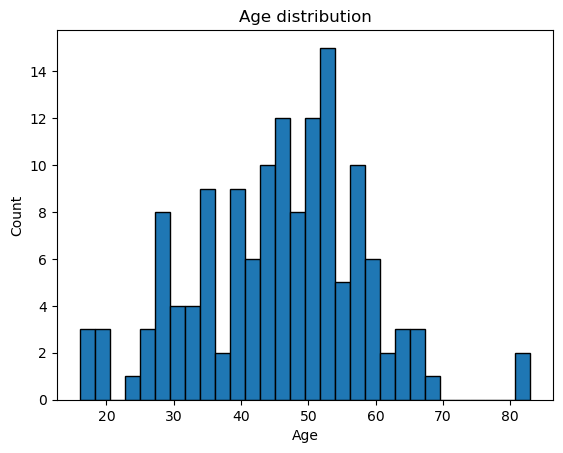

In [14]:
# ------------------------------
# Align samples
common_samples = expr_unique.columns.intersection(meta_scaled.index)
expr_unique = expr_unique[common_samples]
meta_scaled2 = meta_scaled.loc[common_samples]
print(expr_unique.shape)
print(meta_scaled2.shape)

# Plotting Age
plt.hist(meta_scaled2['AgeDeath'], bins=30, edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution")
plt.show()

In [15]:
# ------------------------------
# Keep only samples <30 or >60
meta_subset = meta_scaled2[(meta_scaled2['AgeDeath'] < 30) | (meta_scaled2['AgeDeath'] > 60)].copy()
# Add new variable: 0 = young (<30), 1 = old (>60)
meta_subset['age_group'] = (meta_subset['AgeDeath'] > 60).astype(int)
# Subset expression matrix to the same samples
expr_subset = expr_unique[meta_subset.index]
print(meta_subset.shape, expr_subset.shape)
meta_subset[['AgeDeath', 'age_group']].head()

(29, 13) (9105, 29)


,AgeDeath,age_group
Sample1124_24,29,0
Sample1221_25,28,0
Sample13013_11,28,0
Sample1389_9,61,1
Sample1412_9,28,0


In [16]:
# ------------------------------
# Keep only genes in clock
coefPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv"
# Load coefficients
df_coef = pd.read_csv(coefPath, index_col=0)
# Convert the single-column DataFrame to a Series
coef_series = pd.Series(df_coef['coef'].values, index=df_coef.index, name='coef')
# Ensure it's a Series
coef_series = pd.Series(coef_series, name='coef')
coef = df_coef
genes_to_keep = coef.index
expr_subset = expr_subset.loc[genes_to_keep]
expr_subset.shape

(232, 29)

In [17]:
# ------------------------------
# Prepare data
# ------------------------------
# Keep covariates of interest
covariates = meta_subset[['Sex', 'PMI', 'RIN']].copy()

# One-hot encode Sex if necessary
covariates = pd.get_dummies(covariates, columns=['Sex'], drop_first=True)

# Add intercept
Xcov_only = sm.add_constant(covariates).astype(float)

# Outcome variable: 0 = young, 1 = old
y = meta_subset['age_group'].values

# Align samples with expression matrix
expr_use = expr_subset
common_samples = expr_use.columns.intersection(meta_subset.index)
expr_use = expr_use[common_samples]
Xcov_only = Xcov_only.loc[common_samples]
y = y[np.isin(meta_subset.index, common_samples)]

# ------------------------------
# Fit null logistic model
# ------------------------------
null_model = sm.Logit(y, Xcov_only).fit(disp=0)
p_hat = null_model.predict()

# W matrix: diagonal of p*(1-p)
W = np.diag(p_hat * (1 - p_hat))

# ------------------------------
# Compute z-scores for each gene
# ------------------------------
results = []

for gene_id in expr_use.index:
    x = expr_use.loc[gene_id].values.reshape(-1,1)  # already standardized
    
    # If gene has zero variance, set z=0
    if np.var(x) == 0:
        results.append((gene_id, 0.0))
        continue
    
    # Wald z-score: z = (x^T (y - p_hat)) / sqrt(x^T W x)
    numerator = x.T @ (y - p_hat)
    denominator = np.sqrt(x.T @ W @ x)
    z = float(numerator / denominator)
    
    results.append((gene_id, z))

# ------------------------------
# Compile results
# ------------------------------
deg_z = pd.DataFrame(results, columns=['gene_id','z_expr']).set_index('gene_id')
deg_z.head()

C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_8704\1645415219.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z = float(numerator / denominator)


,z_expr
gene_id,
ENSG00000006210,-2.195107
ENSG00000007516,2.891849
ENSG00000008118,2.935134
ENSG00000008283,2.568948
ENSG00000010818,-1.618684


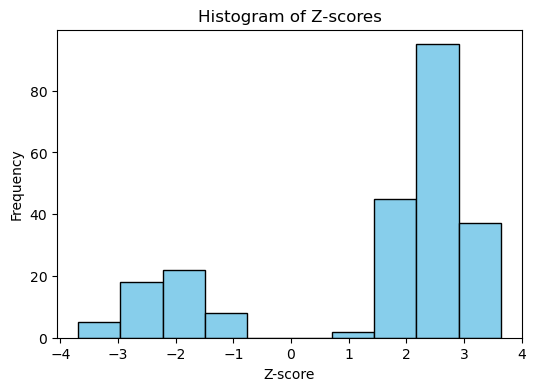

In [18]:
# Plot histogram of the first few genes (deg_z.head())
plt.figure(figsize=(6,4))
plt.hist(deg_z['z_expr'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.title('Histogram of Z-scores')
plt.show()

In [19]:
# ------------------------------
# Start stochastic modelling
# ------------------------------
# Define helper functions
def cov_from_corr_sd(corr: pd.DataFrame, sd: pd.Series) -> pd.DataFrame:
    """Covariance = D * R * D, with D=diag(sd)."""
    D = np.diag(sd.values)
    cov = D @ corr.values @ D
    return pd.DataFrame(cov, index=corr.index, columns=corr.columns)


def shrink_corr_from_matrix(X: pd.DataFrame) -> pd.DataFrame:
    """
    Estimate correlation via Ledoit-Wolf shrinkage
    from an expression matrix (samples x genes).
    X = samples x genes
    """
    Xc = X - X.mean(axis=0)
    lw = LedoitWolf().fit(Xc.values)
    cov = pd.DataFrame(lw.covariance_, index=X.columns, columns=X.columns)
    d = np.sqrt(np.diag(cov.values))
    corr = cov / d[:, None] / d[None, :]
    return corr

In [20]:
# ------------------------------
# Convert z-scores → age-specific means
# ------------------------------
def z_to_means(genes, z_age80_vs_25, space="z",
               baseline_mean_age25=None, baseline_sd_age25=None, se_per_gene=None):
    """
    space = "z": assume standardized space
       - age 25 mean = 0, sd = 1
       - age 80 mean = z
    space = "raw": use delta = z * SE
    """
    z_age80_vs_25 = z_age80_vs_25.reindex(genes)

    if space == "z":
        mean25 = pd.Series(0.0, index=genes)
        sd25   = pd.Series(1.0, index=genes) if baseline_sd_age25 is None else baseline_sd_age25.reindex(genes)
        mean80 = z_age80_vs_25.copy()
        sd80   = sd25.copy()
    elif space == "raw":
        if se_per_gene is None or baseline_mean_age25 is None:
            raise ValueError("Need baseline_mean_age25 and se_per_gene for raw mode")
        mean25 = baseline_mean_age25.reindex(genes)
        sd25   = pd.Series(1.0, index=genes) if baseline_sd_age25 is None else baseline_sd_age25.reindex(genes)
        delta  = z_age80_vs_25 * se_per_gene.reindex(genes)
        mean80 = mean25 + delta
        sd80   = sd25
    else:
        raise ValueError("space must be 'z' or 'raw'")

    return mean25, sd25, mean80, sd80

In [21]:
# ------------------------------
# Adjusted MVN simulation to reduce excessive collinearity
# ------------------------------
def simulate_mvn(n, mean, corr=None, sd=None, jitter=1e-3):
    """
    Simulate multivariate normal samples for genes with slight jitter to reduce
    perfect correlations for better convergence in ElasticNet.

    Parameters
    ----------
    n : int
        Number of samples.
    mean : pd.Series
        Mean per gene.
    corr : pd.DataFrame, optional
        Gene-gene correlation matrix.
    sd : pd.Series, optional
        Standard deviation per gene.
    jitter : float, optional
        Small value to add to diagonal of covariance to reduce collinearity.
    """
    genes = mean.index
    p = len(genes)

    # Default identity correlation / unit SD
    if corr is None:
        corr = pd.DataFrame(np.eye(p), index=genes, columns=genes)
    if sd is None:
        sd = pd.Series(1.0, index=genes)

    # Covariance matrix from correlation and SD
    cov = cov_from_corr_sd(corr, sd)

    # Add small jitter to diagonal to reduce perfect correlation
    cov += np.eye(p) * jitter

    # Draw samples
    X = np.random.multivariate_normal(mean.values, cov.values, size=n)
    return pd.DataFrame(X, columns=genes)

In [22]:
# ------------------------------
# Define a Multivariate Normal simulation
# ------------------------------
def negbin_params_from_mean_k(mu, k):
    n_param = k
    p_param = k / (k + mu)
    return n_param, p_param

def gaussian_copula_transform(n, corr):
    R = corr.values
    Z = np.random.multivariate_normal(mean=np.zeros(len(R)), cov=R, size=n)
    U = stats.norm.cdf(Z)
    return U

def simulate_gaussian_copula_negbin(n, corr, mean_counts, k_overdisp):
    genes = mean_counts.index
    U = gaussian_copula_transform(n, corr)
    out = np.empty_like(U, dtype=np.int64)

    for j, g in enumerate(genes):
        mu = float(mean_counts[g])
        k  = float(k_overdisp[g])
        n_param, p_param = negbin_params_from_mean_k(mu, k)
        out[:, j] = stats.nbinom.ppf(U[:, j], n=n_param, p=p_param).astype(int)

    return pd.DataFrame(out, columns=genes)

In [23]:
# ------------------------------
# Running simulations for ages 20 and 60
# ------------------------------
# This generates 
genes = deg_z.index
z = deg_z

# Convert z-scores → age-specific means in z-space
mean20, sd20, mean60, sd60 = z_to_means(genes, z, space="z")

# Correlation of genes
expr_use_T = expr_use.T  # shape = (samples, genes)
corr = shrink_corr_from_matrix(expr_use_T)

# Ensure 1D Series and alignment
mean20 = mean20.squeeze()
mean60 = mean60.squeeze()
sd20   = sd20.squeeze()
sd60   = sd60.squeeze()

genes_common = mean20.index.intersection(corr.index)
mean20 = mean20.loc[genes_common]
mean60 = mean60.loc[genes_common]
sd20   = sd20.loc[genes_common]
sd60   = sd60.loc[genes_common]
corr   = corr.loc[genes_common, genes_common]

# ---- MVN samples ----
samples20 = simulate_mvn(2000, mean20, corr=corr, sd=sd20)
samples60 = simulate_mvn(2000, mean60, corr=corr, sd=sd60)

samples20["age"] = 20
samples60["age"] = 60
mvn_samples = pd.concat([samples20, samples60], ignore_index=True)

mvn_samples.head()

,ENSG00000006210,ENSG00000007516,ENSG00000008118,ENSG00000008283,ENSG00000010818,ENSG00000011021,ENSG00000012822,ENSG00000021300,ENSG00000022267,ENSG00000036530,...,ENSG00000270882,ENSG00000273079,ENSG00000273084,ENSG00000273301,ENSG00000276952,ENSG00000277869,ENSG00000278195,ENSG00000287769,ENSG00000288612,age
0,-0.562413,0.587627,-0.572211,-0.152168,-1.011247,-0.130081,-0.856207,1.123832,-0.760211,-1.122324,...,0.598085,-0.819084,-0.864231,0.347179,-0.569555,0.068389,-0.170118,-0.162860,-1.154552,20
1,1.095220,-0.817124,-0.991115,0.756155,1.876322,-0.434232,-0.992820,-1.633014,-0.115080,0.960590,...,0.744735,0.387330,-0.195870,0.203401,-0.820622,0.999116,0.768461,-2.336853,-0.795439,20
2,-0.446349,-0.989679,-2.196302,-2.173230,-0.425534,-2.299652,-3.646235,0.321287,-1.069567,-0.669445,...,-2.008280,0.243224,-0.642683,-0.009660,-2.085011,-0.994731,-2.319355,-1.473605,-3.269911,20
3,-0.557534,0.517786,-0.761264,1.471172,-0.675172,0.916299,1.621004,-1.124868,0.059702,0.109025,...,0.087642,0.087584,1.668885,-0.671846,0.771992,-0.182183,0.578697,0.246471,1.815527,20
4,-0.938780,0.096119,1.222090,1.443707,1.482950,0.751383,1.241666,-0.594809,0.235045,1.264524,...,1.568222,-0.253040,0.056324,0.012540,1.451952,1.229257,1.238054,1.171082,2.086361,20


In [24]:
# ------------------------------
# Running Gaussian Copula–NB simulations for ages 20 and 60
# ------------------------------
# This generates COUNTS
# If z is DataFrame with one column
z = z.squeeze()   # now a Series

# Example: map z-scores to mean counts (toy example)
# You can adjust this to your real counts
baseline_mu = pd.Series(100.0, index=genes_common)        # baseline counts
fold_change = np.exp(z[genes_common] * 0.2)              # simple mapping z -> fold change
mu20 = baseline_mu                                        # age 20
mu60 = baseline_mu * fold_change                           # age 60

# Overdispersion parameter k (can be gene-specific)
k20 = pd.Series(10.0, index=genes_common)
k60 = pd.Series(10.0, index=genes_common)

# Simulate
samples20_nb = simulate_gaussian_copula_negbin(2000, corr, mu20, k20)
samples60_nb = simulate_gaussian_copula_negbin(2000, corr, mu60, k60)

# Add age labels
samples20_nb["age"] = 20
samples60_nb["age"] = 60

# Concatenate
copula_nb_samples = pd.concat([samples20_nb, samples60_nb], ignore_index=True)
copula_nb_samples.head()

,ENSG00000006210,ENSG00000007516,ENSG00000008118,ENSG00000008283,ENSG00000010818,ENSG00000011021,ENSG00000012822,ENSG00000021300,ENSG00000022267,ENSG00000036530,...,ENSG00000270882,ENSG00000273079,ENSG00000273084,ENSG00000273301,ENSG00000276952,ENSG00000277869,ENSG00000278195,ENSG00000287769,ENSG00000288612,age
0,86,54,47,84,51,53,90,140,35,69,...,94,58,83,76,109,89,82,91,149,20
1,61,52,49,58,39,27,46,132,40,25,...,41,82,74,139,84,89,44,59,66,20
2,77,95,62,73,91,70,51,146,48,79,...,64,79,104,72,57,76,84,111,74,20
3,89,98,63,60,66,89,96,110,75,123,...,72,89,82,106,93,137,88,96,88,20
4,85,144,121,166,95,178,146,118,158,126,...,112,96,141,92,137,129,156,113,171,20


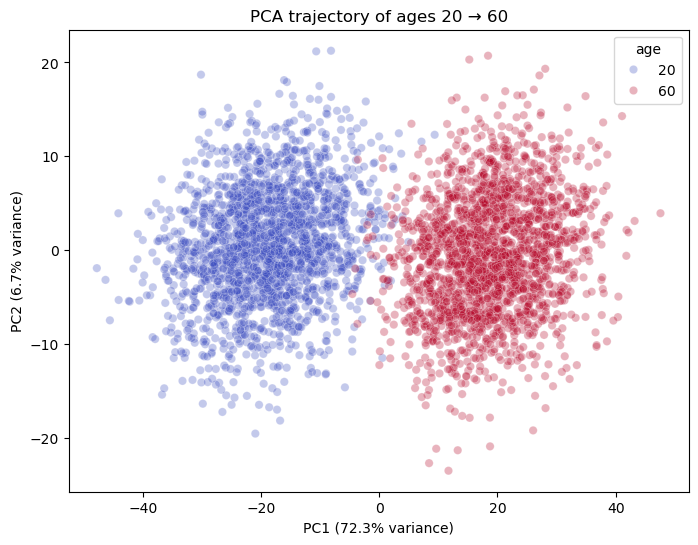

In [25]:
# ------------------------------
# PCA analysis of stochastic genes
# Extract gene expression only
X = mvn_samples.drop(columns=["age"]).values
ages = mvn_samples["age"].values

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

# Wrap into DataFrame
pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["age"] = ages

# Plotting
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="age", palette="coolwarm", alpha=0.3)
plt.title("PCA trajectory of ages 20 → 60")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.show()

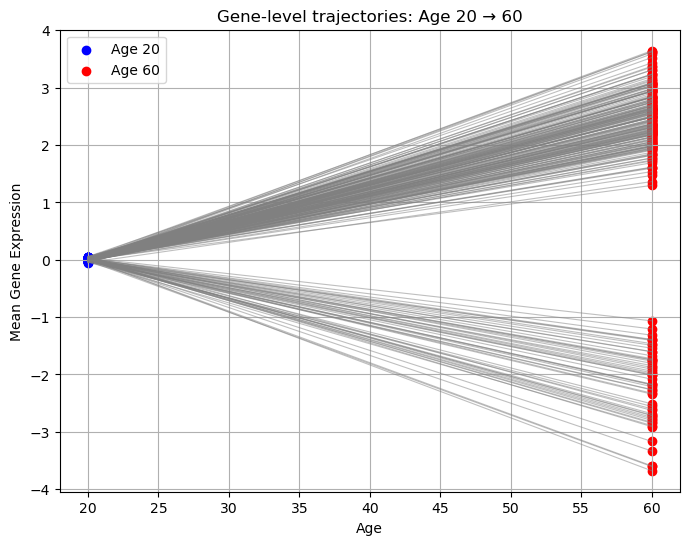

In [26]:
# ------------------------------
# Compute mean expression per gene for each age group
mean_expr = mvn_samples.groupby(['age']).mean().T  # Transpose to have genes as rows
mean_expr = mean_expr.loc[:, [20, 60]]  # Select only ages 20 and 60

# Scatter plots of stochastic genes
plt.figure(figsize=(8, 6))

# Draw a line for each gene
for gene in mean_expr.index:
    plt.plot([20, 60], [mean_expr.loc[gene, 20], mean_expr.loc[gene, 60]],
             color='gray', alpha=0.5, lw=0.8)

# Add points on top
plt.scatter([20]*len(mean_expr), mean_expr[20], color='blue', label='Age 20')
plt.scatter([60]*len(mean_expr), mean_expr[60], color='red', label='Age 60')

plt.xlabel('Age')
plt.ylabel('Mean Gene Expression')
plt.title('Gene-level trajectories: Age 20 → 60')
plt.legend()
plt.grid(True)
plt.show()

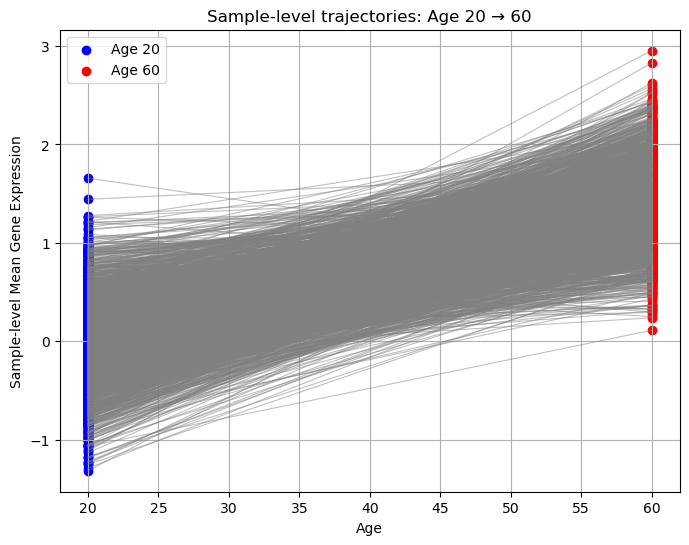

In [27]:
# ------------------------------
# Scatter plots of expression per sample between ages 20 and 60
# ------------------------------
# ------------------------------
# Scatter plots of expression per sample (no sample_id)
# ------------------------------
# Keep only age 20 and 60
samples_20_60 = mvn_samples[mvn_samples['age'].isin([20, 60])]

# Split by age
samples_20 = samples_20_60[samples_20_60['age'] == 20].drop(columns=['age'])
samples_60 = samples_20_60[samples_20_60['age'] == 60].drop(columns=['age'])

plt.figure(figsize=(8, 6))

# Loop over rows (each row = one sample’s expression vector)
for i in range(min(len(samples_20), len(samples_60))):
    plt.plot([20, 60],
             [samples_20.iloc[i].mean(), samples_60.iloc[i].mean()],
             color='gray', alpha=0.5, lw=0.8)

# Scatter points
plt.scatter([20]*len(samples_20), samples_20.mean(axis=1),
            color='blue', label='Age 20')
plt.scatter([60]*len(samples_60), samples_60.mean(axis=1),
            color='red', label='Age 60')

plt.xlabel('Age')
plt.ylabel('Sample-level Mean Gene Expression')
plt.title('Sample-level trajectories: Age 20 → 60')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# ------------------------------
# Age range and interpolation
# ------------------------------
ages = [20, 30, 40, 50, 60]

# Interpolate gene means for each age
mean_df = pd.DataFrame(index=genes_common, columns=ages, dtype=float)
for gene in genes_common:
    mean_df.loc[gene] = np.linspace(mean20[gene], mean60[gene], num=len(ages))

# Optional: interpolate SDs across ages
sd_df = pd.DataFrame(index=genes_common, columns=ages, dtype=float)
for gene in genes_common:
    sd_df.loc[gene] = np.linspace(sd20[gene], sd60[gene], num=len(ages))

# ------------------------------
# Generate MVN samples for each age
# ------------------------------
n_samples_per_age = 2000
all_samples = []

for age in ages:
    mean_vec = mean_df[age].astype(float)
    sd_vec   = sd_df[age].astype(float)
    
    samples_age = simulate_mvn(n_samples_per_age, mean_vec, corr=corr, sd=sd_vec)
    samples_age["age"] = age
    all_samples.append(samples_age)

# Combine all ages
mvn_samples_multi_age = pd.concat(all_samples, ignore_index=True)
mvn_samples_multi_age.head()

,ENSG00000006210,ENSG00000007516,ENSG00000008118,ENSG00000008283,ENSG00000010818,ENSG00000011021,ENSG00000012822,ENSG00000021300,ENSG00000022267,ENSG00000036530,...,ENSG00000270882,ENSG00000273079,ENSG00000273084,ENSG00000273301,ENSG00000276952,ENSG00000277869,ENSG00000278195,ENSG00000287769,ENSG00000288612,age
0,-0.891409,1.435646,0.385166,0.829027,-1.045619,1.224664,-0.757300,-0.447894,1.203216,-1.116655,...,-1.533892,-0.333358,0.438810,0.738200,-0.035062,-0.087838,-0.219093,-1.266650,1.044878,20
1,0.298604,-0.965243,-1.483553,-0.698142,-0.391728,-1.429830,0.069381,-1.117966,0.368145,0.050022,...,-0.924573,-0.445328,-0.665183,0.619280,-1.232593,-0.566614,0.101555,-2.205052,0.566261,20
2,-0.589363,-0.363186,0.549789,0.315288,-0.268761,0.038727,1.103233,-1.060390,0.068122,0.150982,...,0.011154,-0.181263,0.343395,0.624715,1.098422,0.698013,0.075746,-0.421472,-0.061026,20
3,-0.835842,-0.510856,-1.155920,0.432333,-0.375660,-0.732692,-1.600920,-0.688227,0.034792,-0.646610,...,-0.541472,0.825168,-0.469244,0.030101,-0.872104,-0.098707,-1.718803,-0.068313,-0.338304,20
4,-0.089803,-0.122650,-0.871821,-0.711924,-0.672221,-0.796128,-1.695243,0.703089,-2.242360,-0.707913,...,-1.360874,0.148570,0.238941,-0.065859,-1.200168,0.342178,-0.585963,-1.332067,-1.027334,20


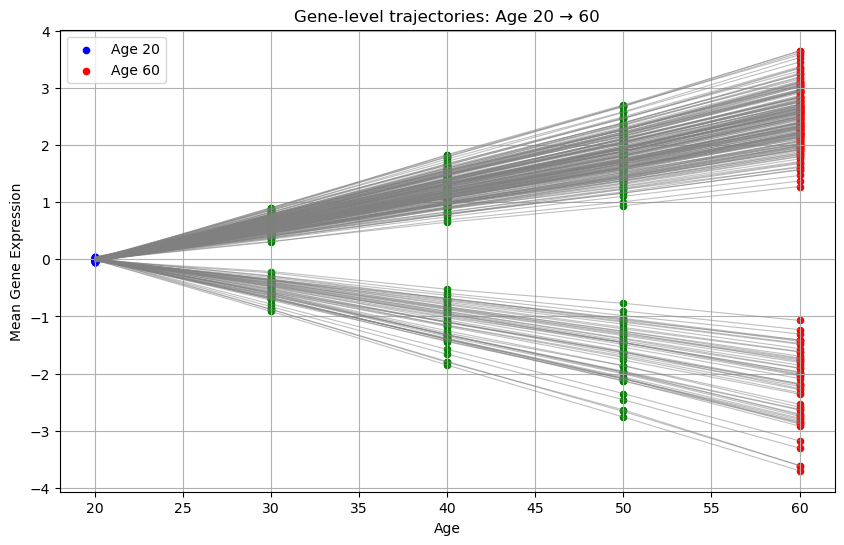

In [29]:
# Compute mean expression per gene for each age group
mean_expr = mvn_samples_multi_age.groupby('age').mean().T  # genes as rows

# Optional: select a subset of ages to plot
ages_to_plot = [20, 30, 40, 50, 60]
mean_expr = mean_expr.loc[:, ages_to_plot]

# Plot
plt.figure(figsize=(10, 6))

# Draw a line for each gene
for gene in mean_expr.index:
    plt.plot(ages_to_plot, mean_expr.loc[gene, ages_to_plot],
             color='gray', alpha=0.5, lw=0.8)

# Add points on top
for age in ages_to_plot:
    plt.scatter([age]*len(mean_expr), mean_expr[age],
                label=f'Age {age}' if age in [20, 60] else "",  # label only 20 & 60
                s=20,
                color='blue' if age==20 else 'red' if age==60 else 'green')

plt.xlabel('Age')
plt.ylabel('Mean Gene Expression')
plt.title('Gene-level trajectories: Age 20 → 60')
plt.legend()
plt.grid(True)
plt.show()

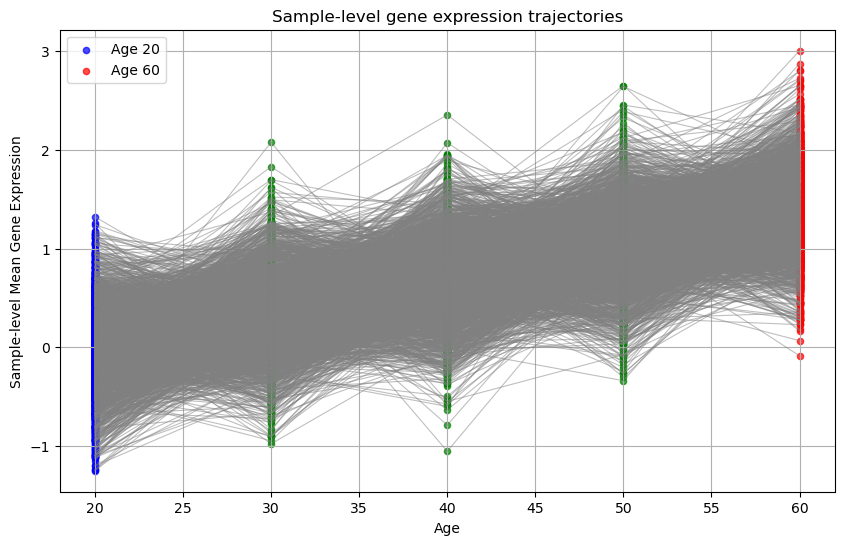

In [30]:
# ------------------------------
# Sample-level trajectories across ages
# ------------------------------
ages_to_plot = [20, 30, 40, 50, 60]
samples_multi_age = mvn_samples_multi_age[mvn_samples_multi_age['age'].isin(ages_to_plot)]

plt.figure(figsize=(10, 6))

# Pivot: rows = sample index, cols = ages, values = mean expression
sample_means = samples_multi_age.drop(columns=['age']).mean(axis=1)  # per-sample mean
sample_means = pd.DataFrame({
    "age": samples_multi_age['age'].values,
    "mean_expr": sample_means.values
})

# Group by index position (pseudo-IDs) across ages
for idx in range(sample_means.shape[0] // len(ages_to_plot)):
    subset = sample_means.iloc[idx::(sample_means.shape[0] // len(ages_to_plot))]
    plt.plot(subset["age"], subset["mean_expr"], color="gray", alpha=0.5, lw=0.8)

# Scatter points on top
for age in ages_to_plot:
    subset = sample_means[sample_means['age'] == age]
    plt.scatter([age]*len(subset), subset['mean_expr'],
                color='blue' if age==20 else 'red' if age==60 else 'green',
                alpha=0.7, s=20, label=f'Age {age}' if age in [20, 60] else "")

plt.xlabel('Age')
plt.ylabel('Sample-level Mean Gene Expression')
plt.title('Sample-level gene expression trajectories')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_8704\66592744.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expr_use_aligned.T.groupby(age_bins).mean().T  # genes x bins


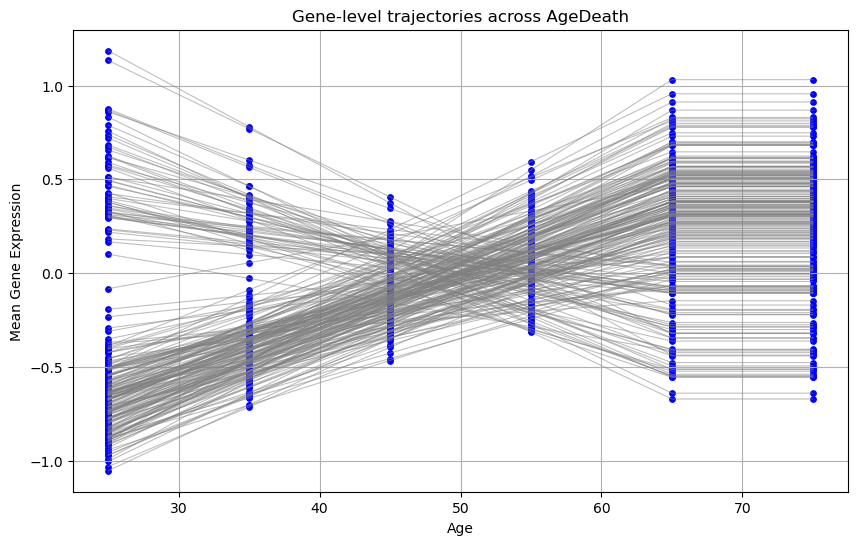

In [31]:
# ------------------------------
# Align samples
# ------------------------------
common_samples = expr_use.columns.intersection(meta_subset.index)
expr_use_aligned = expr_use[common_samples]
age_series = meta_subset.loc[common_samples, 'AgeDeath']

# ------------------------------
# Define age bins
# ------------------------------
bins = [20, 30, 40, 50, 60, 70, 80]  # adjust as needed
age_bins = pd.cut(age_series, bins=bins, right=False)

# Compute mean expression per gene per age bin
mean_expr = expr_use_aligned.T.groupby(age_bins).mean().T  # genes x bins

# Compute numeric bin centers
bin_centers = [interval.left + (interval.right - interval.left)/2 for interval in mean_expr.columns]

# Ensure numeric values and fill missing
mean_expr_numeric = mean_expr.copy()
mean_expr_numeric = mean_expr_numeric.astype(float).interpolate(axis=1)  # fill NaNs if any

# Plot
plt.figure(figsize=(10, 6))

for gene in mean_expr_numeric.index:
    y = mean_expr_numeric.loc[gene, :].values  # numeric values across bins
    plt.plot(bin_centers, y, color='gray', alpha=0.5, lw=0.8)

# Overlay points for each bin
for i, center in enumerate(bin_centers):
    plt.scatter([center]*len(mean_expr_numeric),
                mean_expr_numeric.iloc[:, i].values,
                color='blue', s=15)

plt.xlabel('Age')
plt.ylabel('Mean Gene Expression')
plt.title('Gene-level trajectories across AgeDeath')
plt.grid(True)
plt.show()

In [32]:
# ------------------------------
# Model training
# ------------------------------
def train_elastic_net(
    z_expr: pd.DataFrame,
    y_age: pd.Series,
    selected_genes: List[str],
    n_splits: int = 5,
    random_state: int = 42,
    l1_ratios: Tuple[float, ...] = (0.1, 0.3, 0.5, 0.7, 0.9)
) -> Tuple[ElasticNetCV, dict]:
    """Fit ElasticNetCV on selected genes, return model and CV metrics."""
    
    # Align genes and transpose so samples are rows
    X = z_expr.loc[selected_genes].T
    y = y_age.loc[X.index]  # ensure samples match
    
    # Initialize CV
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Fit ElasticNetCV on all data
    model = ElasticNetCV(l1_ratio=l1_ratios, alphas=None, cv=cv, max_iter=1000)
    model.fit(X, y)
    
    # Out-of-fold predictions
    preds = np.zeros(len(y), dtype=float)
    for train_idx, test_idx in cv.split(X):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr = y.iloc[train_idx]
        m = ElasticNetCV(l1_ratio=l1_ratios, alphas=None, cv=cv, max_iter=1000)
        m.fit(Xtr, ytr)
        preds[test_idx] = m.predict(Xte)
    
    # CV metrics
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    metrics = {"cv_r2": float(r2), "cv_mae": float(mae)}
    
    return model, metrics

In [33]:
# ------------------------------
# Model training
# ------------------------------
# Features: genes x samples
# Drop the 'age' column from simulated data
X_sim = mvn_samples_multi_age.drop(columns=['age'])
y_sim = mvn_samples_multi_age['age']

# Features: genes x samples
X_sim_selected = X_sim[genes]      # genes are currently columns
X_sim_selected = X_sim_selected.T   # now genes are rows, samples are columns

# Train the model
model, metrics = train_elastic_net(
    z_expr=X_sim_selected,  # or X_sim if using all genes
    y_age=y_sim,
    selected_genes=genes,  # can be None to use all genes
    n_splits=5,
    random_state=42,
    l1_ratios=(0.1, 0.3, 0.5, 0.7, 0.9)
)

C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 301.5091650521499, tolerance: 160.03928
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 463.51030086536775, tolerance: 160.03928
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 240.93519806329277, tolerance: 160.03928
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\sklearn\l

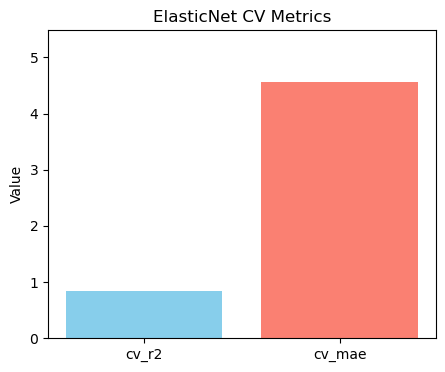

In [34]:
# ------------------------------
# Plotting metrics
# ------------------------------
# Convert to lists for plotting
names = list(metrics.keys())
values = list(metrics.values())

# Create bar plot
plt.figure(figsize=(5, 4))
plt.bar(names, values, color=['skyblue', 'salmon'])
plt.ylabel("Value")
plt.title("ElasticNet CV Metrics")
plt.ylim(0, max(values)*1.2)  # add some space on top
plt.show()

In [35]:
# ------------------------------
# Saving Coefficients
# ------------------------------
# Coefficients as Series (gene names as index)
coef_series = pd.Series(model.coef_, index=genes, name='coef')
coef_series.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/01elastic_net_coefficients-08152025.csv", header=True)

# Optional only non-zero coeficients
nonzero_coef = coef_series[coef_series != 0]
nonzero_coef.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv", header=True)

# Print intercept
print("Intercept:", model.intercept_)

# Save intercept
pd.Series({"intercept": model.intercept_}).to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/03elastic_net_intercept-08152025.csv"
)

Intercept: 23.333995032830888


In [36]:
# ------------------------------
# Predicting with Coefficients
# ------------------------------
# Expression matrix for excluded samples
expr_excluded = expr_z
# Make sure the same genes are used (selected_genes)
X_excluded = expr_excluded.loc[genes]

# Load coefficients
df_coef = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv", index_col=0)
# Convert the single-column DataFrame to a Series
coef_series = pd.Series(df_coef['coef'].values, index=df_coef.index, name='coef')
# Ensure it's a Series
coef_series = pd.Series(coef_series, name='coef')
# Subset new expression matrix to selected genes
X_new = X_excluded.loc[coef_series.index].T  # samples x genes

# Load the intercept CSV
df_intercept = pd.read_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/00elasticnet-08152025/03elastic_net_intercept-08152025.csv",
    index_col=0
)

# Extract the value
intercept = df_intercept.loc["intercept"].values[0]

# Dot product to get predicted age
predicted_age = X_new.dot(coef_series) + intercept

# Convert to Series
predicted_age = pd.Series(predicted_age, index=X_new.index, name='Predicted_Age')

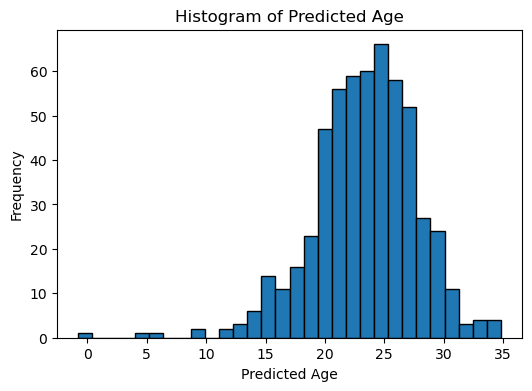

In [37]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_age, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

Correlation between predicted and AgeDeath: 0.354


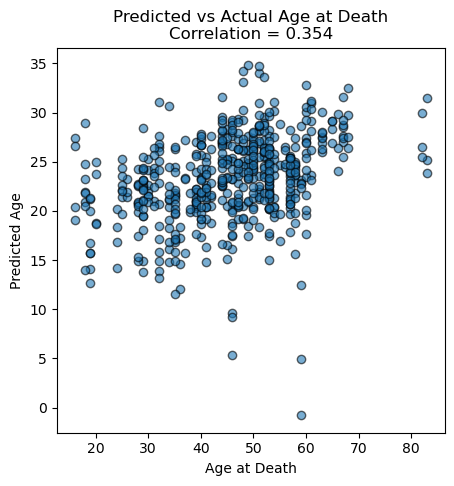

In [38]:
# Now align with predicted_age
common_ids = predicted_age.index.intersection(meta_scaled.index)
ages = meta_scaled.loc[common_ids, "AgeDeath"]
pred = predicted_age.loc[common_ids]

# Correlation
corr = pred.corr(ages)
print(f"Correlation between predicted and AgeDeath: {corr:.3f}")

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(ages, pred, alpha=0.6, edgecolor="k")
plt.xlabel("Age at Death")
plt.ylabel("Predicted Age")
plt.title(f"Predicted vs Actual Age at Death\nCorrelation = {corr:.3f}")
plt.show()

In [62]:
# ------------------------------
# Training Deep Learning Model
# ------------------------------
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Define a flexible Keras model
def create_model(trial, input_dim):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    model = Sequential()
    
    for i in range(n_layers):
        units = trial.suggest_int(f"units_l{i}", 32, 512, step=32)
        dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.5)
        
        if i == 0:
            model.add(Dense(
                units, activation='relu', input_dim=input_dim,
                kernel_initializer=GlorotUniform(seed=42)
            ))
        else:
            model.add(Dense(
                units, activation='relu',
                kernel_initializer=GlorotUniform(seed=42)
            ))
        
        # Fix dropout randomness
        model.add(Dropout(dropout_rate, seed=42))
    
    # Output layer
    model.add(Dense(1, activation='linear', kernel_initializer=GlorotUniform(seed=42)))
    
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

In [65]:
# ------------------------------
# Training deep models from the Elastic Net with cross-validation
# ------------------------------
# Setting seeds for replicability
seed = 42
np.random.seed(seed)

# Adjust shape of samples
X_sim_selected = X_sim[genes]      # genes are currently columns

# Specify folder to save models
# change this to your desired path
MODEL_SAVE_PATH = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Define a function
def objective(trial):
    # Create model with trial hyperparameters
    model = create_model(trial, input_dim=X_sim_selected.shape[1])
    
    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(X_sim_selected, y_sim, test_size=0.2, random_state=42)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        callbacks=[es],
        verbose=0
    )
    
    # Save the trained model in the specified folder
    model_filename = os.path.join(MODEL_SAVE_PATH, f"trial_{trial.number}_model.h5")
    model.save(model_filename)
    print(f"Saved model for trial {trial.number} as {model_filename}")
    
    # Return validation metric for optimization
    val_mae = min(history.history['val_mae'])
    return val_mae

# Run Optuna optimization
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

# Print best trial
print("Best trial:")
trial = study.best_trial
print(trial.params)

[I 2025-08-19 18:56:19,613] A new study created in memory with name: no-name-8752fc83-d2d4-4940-b1e6-552e99b324b1
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-08-19 18:56:42,379] Trial 0 finished with value: 4.679035186767578 and parameters: {'n_layers': 2, 'units_l0': 512, 'dropout_l0': 0.36599697090570255, 'units_l1': 320, 'dropout_l1': 0.07800932022121826, 'learning_rate': 0.00020511104188433984, 'batch_size': 32}. Best is trial 0 with value: 4.679035186767578.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `In

Saved model for trial 0 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_0_model.h5


[I 2025-08-19 18:57:13,425] Trial 1 finished with value: 4.5342020988464355 and parameters: {'n_layers': 1, 'units_l0': 512, 'dropout_l0': 0.41622132040021087, 'learning_rate': 0.00026587543983272726, 'batch_size': 128}. Best is trial 1 with value: 4.5342020988464355.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved model for trial 1 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_1_model.h5


[I 2025-08-19 18:57:28,556] Trial 2 finished with value: 4.5684943199157715 and parameters: {'n_layers': 2, 'units_l0': 160, 'dropout_l0': 0.30592644736118974, 'units_l1': 96, 'dropout_l1': 0.14607232426760908, 'learning_rate': 0.0005404103854647331, 'batch_size': 32}. Best is trial 1 with value: 4.5342020988464355.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Saved model for trial 47 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_47_model.h5


[I 2025-08-19 19:23:27,566] Trial 48 finished with value: 4.48472785949707 and parameters: {'n_layers': 1, 'units_l0': 64, 'dropout_l0': 0.264445969537555, 'learning_rate': 0.0004980804153608572, 'batch_size': 64}. Best is trial 47 with value: 4.452132225036621.
C:\Users\jjm262\AppData\Local\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved model for trial 48 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_48_model.h5


[I 2025-08-19 19:23:49,889] Trial 49 finished with value: 10.004271507263184 and parameters: {'n_layers': 3, 'units_l0': 160, 'dropout_l0': 0.43611112506430855, 'units_l1': 320, 'dropout_l1': 0.20950349985014083, 'units_l2': 384, 'dropout_l2': 0.46166793061323796, 'learning_rate': 0.0011619781420486681, 'batch_size': 64}. Best is trial 47 with value: 4.452132225036621.


Saved model for trial 49 as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_49_model.h5
Best trial:
{'n_layers': 1, 'units_l0': 64, 'dropout_l0': 0.49767148391082966, 'learning_rate': 0.0005064315006190957, 'batch_size': 64}


In [66]:
# Build path to best model
best_model_filename = os.path.join(MODEL_SAVE_PATH, f"trial_{study.best_trial.number}_model.h5")
print(best_model_filename)
# Print best trial
print("Best trial:")
trial = study.best_trial
print(trial.params)

C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_47_model.h5
Best trial:
{'n_layers': 1, 'units_l0': 64, 'dropout_l0': 0.49767148391082966, 'learning_rate': 0.0005064315006190957, 'batch_size': 64}


In [67]:
# ------------------------------
# Prepare data for prediction
# ------------------------------
# Filter expr_excluded to only these genes
expr_excluded_filtered = expr_z[excluded_cols].loc[genes.intersection(expr_z.index)]

# Transpose to samples x genes
X_excluded = expr_excluded_filtered.T
X_excluded.shape

(408, 232)

In [72]:
# ------------------------------
# Load the best model (without compiling)
# ------------------------------
best_model_filename = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_47_model.h5"
best_model = load_model(best_model_filename, compile=False)
print(f"Loaded best model from {best_model_filename}")

# ------------------------------
# Re-compile the model with standard loss/metrics
# ------------------------------
best_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ------------------------------
# Save under a new name
# ------------------------------
new_model_filename = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00Stochasticdeepclock-08192025.h5"
best_model.save(new_model_filename)
print(f"Saved model as {new_model_filename}")

# ------------------------------
# Predict on new data
# ------------------------------
# X_excluded should have the same shape/features as the training data
predicted_values = best_model.predict(X_excluded)
print("Predictions shape:", predicted_values.shape)

# ------------------------------
# Predict
# ------------------------------
predicted_values = best_model.predict(X_excluded)
print(predicted_values.shape)

Loaded best model from C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/01deeplearning-08162025/trial_47_model.h5
Saved model as C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/00Stochasticdeepclock-08192025.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predictions shape: (408, 1)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(408, 1)


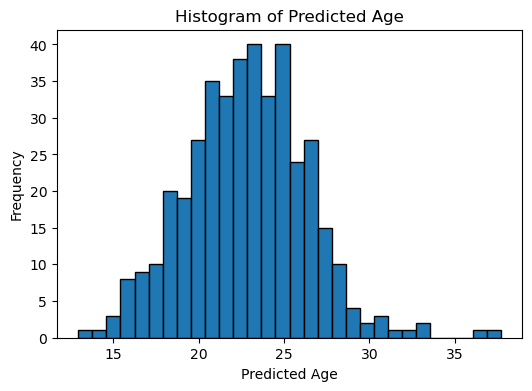

In [73]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_values, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

Correlation between predicted and AgeDeath: 0.175


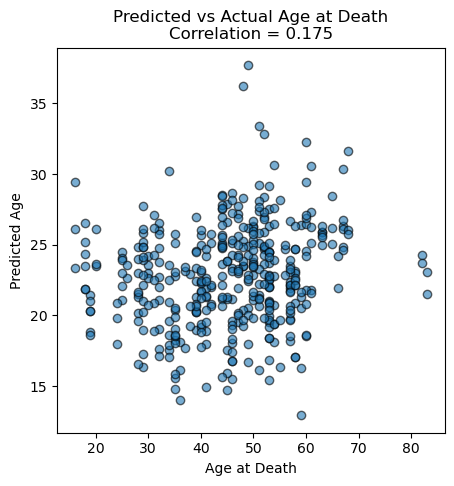

In [74]:
# Assume X_excluded has samples as rows and their index contains the sample IDs
pred = pd.Series(predicted_values.flatten(), index=X_excluded.index, name="PredictedAge")

# Align with actual ages
common_ids = pred.index.intersection(meta_scaled.index)
ages = meta_scaled.loc[common_ids, "AgeDeath"]
pred = pred.loc[common_ids]


# Correlation
corr = pred.corr(ages)
print(f"Correlation between predicted and AgeDeath: {corr:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(ages, pred, alpha=0.6, edgecolor="k")
plt.xlabel("Age at Death")
plt.ylabel("Predicted Age")
plt.title(f"Predicted vs Actual Age at Death\nCorrelation = {corr:.3f}")
plt.show()

In [75]:
# Saving predictions
# Create a DataFrame with sample IDs and predicted age
common_index = predicted_age.index.intersection(pred.index)

df_pred = pd.DataFrame({
    "SampleID": common_index,
    "Predicted_Age_stochastic_elastic": predicted_age.loc[common_index].values,
    "Predicted_Age_stochastic_deep": pred.loc[common_index].values
})

# Save to CSV
df_pred.to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/07stochasticclock-08172025/04vabb_prediction-08152025.csv", 
    index=False
)

print("Predicted ages saved to 'predicted_age_samples.csv'.")

Predicted ages saved to 'predicted_age_samples.csv'.
